# Projeção e mínimos quadrados

**Tema:** Álgebra Linear e Otimização › Vetores, Matrizes e Projeções

Este notebook deriva a regressão linear **da geometria**, não da fórmula. Ao
final, $\hat\beta = (X^\top X)^{-1}X^\top y$ deixa de ser algo a decorar e passa
a ser a consequência óbvia de uma pergunta simples: *qual ponto do plano está
mais perto de mim?*

> **O problema:** você quer resolver $X\beta = y$, mas $y$ não está no espaço
> coluna de $X$. Não existe combinação das features que reproduza o alvo
> exatamente. Se não dá para alcançar $y$, alcance o **ponto mais próximo**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

rng = np.random.default_rng(1234)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
np.set_printoptions(precision=4, suppress=True)
print("pronto")

pronto


## 1. Projeção sobre uma reta: o caso mais simples

Projetar $y$ sobre a direção de um único vetor $a$: qual múltiplo de $a$ está
mais perto de $y$?

$$\hat{y} = \frac{\langle a, y \rangle}{\langle a, a \rangle} a$$

a       = [3. 1.]
y       = [2. 4.]
coef    = 1.0000
y_hat   = [3. 1.]   (a projeção)
resíduo = [-1.  3.]

<a, resíduo> = 0.00e+00   <- ZERO: é isso que 'ortogonal' significa
|y|² = 20.0000 = |y_hat|² + |resíduo|² = 10.0000 + 10.0000 = 20.0000   <- Pitágoras


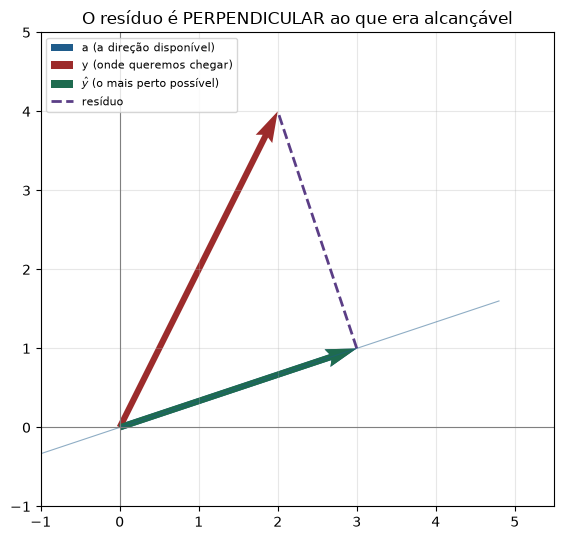

In [2]:
a = np.array([3.0, 1.0])
y = np.array([2.0, 4.0])

coef = np.dot(a, y) / np.dot(a, a)
y_hat = coef * a
residuo = y - y_hat

print(f"a       = {a}")
print(f"y       = {y}")
print(f"coef    = {coef:.4f}")
print(f"y_hat   = {y_hat}   (a projeção)")
print(f"resíduo = {residuo}")
print(f"\n<a, resíduo> = {np.dot(a, residuo):.2e}   <- ZERO: é isso que 'ortogonal' significa")
print(f"|y|² = {np.dot(y,y):.4f} = |y_hat|² + |resíduo|² = "
      f"{np.dot(y_hat,y_hat):.4f} + {np.dot(residuo,residuo):.4f} "
      f"= {np.dot(y_hat,y_hat)+np.dot(residuo,residuo):.4f}   <- Pitágoras")

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.quiver(0, 0, *a, angles="xy", scale_units="xy", scale=1, color=AZUL, width=0.012,
          label="a (a direção disponível)")
ax.quiver(0, 0, *y, angles="xy", scale_units="xy", scale=1, color=VERMELHO, width=0.012,
          label="y (onde queremos chegar)")
ax.quiver(0, 0, *y_hat, angles="xy", scale_units="xy", scale=1, color=VERDE, width=0.012,
          label=r"$\hat{y}$ (o mais perto possível)")
ax.plot([y_hat[0], y[0]], [y_hat[1], y[1]], color=ROXO, lw=2, ls="--", label="resíduo")
t = np.linspace(-0.4, 1.6, 10)
ax.plot(t * a[0], t * a[1], color=AZUL, lw=0.8, alpha=0.5)
ax.set_xlim(-1, 5.5); ax.set_ylim(-1, 5); ax.set_aspect("equal")
ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
ax.legend(fontsize=8, loc="upper left")
ax.set_title("O resíduo é PERPENDICULAR ao que era alcançável")
plt.tight_layout(); plt.show()

**A projeção minimiza a distância — verifique.** Nenhum outro múltiplo de $a$
chega mais perto de $y$.

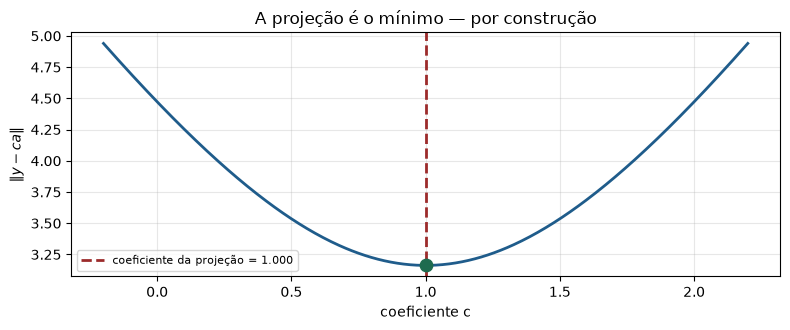

In [3]:
coeficientes = np.linspace(coef - 1.2, coef + 1.2, 400)
distancias = [np.linalg.norm(y - c * a) for c in coeficientes]

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(coeficientes, distancias, color=AZUL, lw=2)
ax.axvline(coef, color=VERMELHO, lw=2, ls="--", label=f"coeficiente da projeção = {coef:.3f}")
ax.scatter([coef], [np.linalg.norm(residuo)], color=VERDE, s=80, zorder=3)
ax.set_xlabel("coeficiente c"); ax.set_ylabel(r"$\|y - ca\|$")
ax.set_title("A projeção é o mínimo — por construção")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 2. Projeção sobre um plano: regressão com 2 features

Agora $X$ tem duas colunas. O conjunto alcançável é um **plano** em
$\mathbb{R}^3$, e a projeção é o pé da perpendicular a esse plano.

beta   = [1.5 2.5]
y_proj = [1.5 2.5 2. ]
resíduo= [-0.5 -0.5  1. ]

X^T @ resíduo = [ 0. -0.]   <- ZERO em TODAS as colunas
É essa condição — resíduo ortogonal a cada feature — que gera a fórmula.


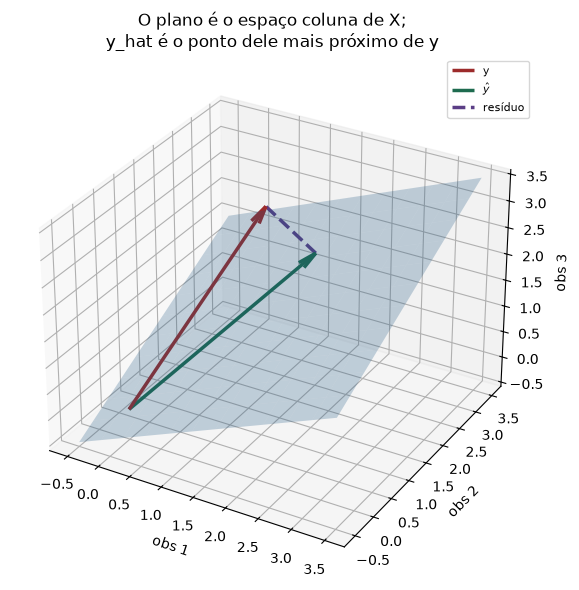

In [4]:
X = np.array([[1.0, 0.0],
              [0.0, 1.0],
              [0.5, 0.5]])
y3 = np.array([1.0, 2.0, 3.0])

beta, *_ = np.linalg.lstsq(X, y3, rcond=None)
y_proj = X @ beta
res = y3 - y_proj

print(f"beta   = {beta}")
print(f"y_proj = {y_proj}")
print(f"resíduo= {res}")
print(f"\nX^T @ resíduo = {X.T @ res}   <- ZERO em TODAS as colunas")
print("É essa condição — resíduo ortogonal a cada feature — que gera a fórmula.")

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
s, t = np.meshgrid(np.linspace(-0.5, 3.5, 12), np.linspace(-0.5, 3.5, 12))
plano = s[..., None] * X[:, 0] + t[..., None] * X[:, 1]
ax.plot_surface(plano[..., 0], plano[..., 1], plano[..., 2], alpha=0.25, color=AZUL)
ax.quiver(0, 0, 0, *y3, color=VERMELHO, lw=2.5, arrow_length_ratio=0.08, label="y")
ax.quiver(0, 0, 0, *y_proj, color=VERDE, lw=2.5, arrow_length_ratio=0.08,
          label=r"$\hat{y}$")
ax.plot(*zip(y_proj, y3), color=ROXO, lw=2.5, ls="--", label="resíduo")
ax.set_xlabel("obs 1"); ax.set_ylabel("obs 2"); ax.set_zlabel("obs 3")
ax.set_title("O plano é o espaço coluna de X;\ny_hat é o ponto dele mais próximo de y")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

> **A mudança de perspectiva que confunde no começo:** neste gráfico, cada
> **eixo é uma observação**, não uma feature. O espaço tem $n = 3$ dimensões, e
> as duas colunas de $X$ geram um plano dentro dele. É o "espaço das
> observações", e é onde a geometria da regressão vive.

## 3. Derivando as equações normais

A única exigência: o resíduo é ortogonal a **todas** as colunas de $X$.

$$X^\top(y - X\beta) = 0
\;\Longrightarrow\; X^\top X\beta = X^\top y
\;\Longrightarrow\; \hat\beta = (X^\top X)^{-1}X^\top y$$

In [5]:
n, p = 500, 3
X = np.column_stack([np.ones(n), rng.normal(0, 1, n), rng.normal(0, 2, n)])
beta_real = np.array([5.0, 2.0, -1.5])
y = X @ beta_real + rng.normal(0, 1.2, n)

beta_normal = np.linalg.inv(X.T @ X) @ X.T @ y      # didático, NÃO usar em produção
beta_solve = np.linalg.solve(X.T @ X, X.T @ y)
beta_lstsq, *_ = np.linalg.lstsq(X, y, rcond=None)
Q, R = np.linalg.qr(X)
beta_qr = np.linalg.solve(R, Q.T @ y)

print(f"{'método':<32s} {'coeficientes':>36s}")
print("-" * 70)
for nome, b in [("verdadeiro", beta_real),
                ("inv(X'X) X'y  (não use)", beta_normal),
                ("solve(X'X, X'y)", beta_solve),
                ("lstsq (SVD)", beta_lstsq),
                ("QR", beta_qr)]:
    print(f"{nome:<32s} {np.array2string(b, precision=6):>36s}")

método                                                   coeficientes
----------------------------------------------------------------------
verdadeiro                                           [ 5.   2.  -1.5]
inv(X'X) X'y  (não use)               [ 5.013194  1.955095 -1.449785]
solve(X'X, X'y)                       [ 5.013194  1.955095 -1.449785]
lstsq (SVD)                           [ 5.013194  1.955095 -1.449785]
QR                                    [ 5.013194  1.955095 -1.449785]


## 4. A matriz chapéu H

$$H = X(X^\top X)^{-1}X^\top, \qquad \hat{y} = Hy$$

$H$ é o operador de projeção. As propriedades dela explicam vários conceitos de
regressão de uma vez.

In [6]:
H = X @ np.linalg.inv(X.T @ X) @ X.T

print(f"H é simétrica?     {np.allclose(H, H.T)}")
print(f"H é idempotente?   {np.allclose(H @ H, H)}   (projetar 2x = projetar 1x)")
print(f"traço de H         {np.trace(H):.6f}   <- exatamente p = {p}")
print(f"autovalores de H   apenas 0 e 1? "
      f"{np.allclose(np.sort(np.unique(np.round(np.linalg.eigvalsh(H), 6))), [0., 1.])}")

I = np.eye(n)
residuos = (I - H) @ y
print(f"\nI - H projeta no espaço ORTOGONAL às features:")
print(f"  traço(I - H) = {np.trace(I - H):.4f}  <- n - p = {n - p}  (graus de liberdade!)")
print(f"  X' @ resíduos = {np.abs(X.T @ residuos).max():.2e}  (zero)")

# alavancagem: a diagonal de H mede a influência de cada ponto
alavancagem = np.diag(H)
print(f"\nalavancagem (diag de H): média {alavancagem.mean():.6f} = p/n = {p/n:.6f}")
print(f"  máxima: {alavancagem.max():.4f}  (pontos com h_ii > 2p/n = "
      f"{2*p/n:.4f} merecem atenção: {(alavancagem > 2*p/n).sum()} pontos)")

H é simétrica?     True
H é idempotente?   True   (projetar 2x = projetar 1x)
traço de H         3.000000   <- exatamente p = 3
autovalores de H   apenas 0 e 1? True

I - H projeta no espaço ORTOGONAL às features:
  traço(I - H) = 497.0000  <- n - p = 497  (graus de liberdade!)
  X' @ resíduos = 7.35e-13  (zero)

alavancagem (diag de H): média 0.006000 = p/n = 0.006000
  máxima: 0.0343  (pontos com h_ii > 2p/n = 0.0120 merecem atenção: 32 pontos)


**O que a matriz chapéu explica de graça:**

| Conceito de regressão | Fato geométrico |
|---|---|
| graus de liberdade $n-p$ | dimensão do espaço dos resíduos, $\operatorname{tr}(I-H)$ |
| alavancagem $h_{ii}$ | quanto o ponto $i$ puxa a própria previsão |
| resíduos ortogonais às features | $X^\top(I-H)y = 0$ por construção |
| $\hat\sigma^2 = \mathrm{SQR}/(n-p)$ | dividir pela dimensão certa |

## 5. R² é um cosseno ao quadrado, e a ANOVA é Pitágoras

In [7]:
y_hat = H @ y
e = y - y_hat
y_barra = y.mean()

sqt = np.sum((y - y_barra) ** 2)
sqe = np.sum((y_hat - y_barra) ** 2)
sqr = np.sum(e ** 2)

print(f"SQ Total     {sqt:>12.4f}")
print(f"SQ Explicada {sqe:>12.4f}")
print(f"SQ Residual  {sqr:>12.4f}")
print(f"SQE + SQR    {sqe + sqr:>12.4f}   <- Pitágoras no espaço das observações\n")

r2 = sqe / sqt
yc, yhc = y - y_barra, y_hat - y_barra
cos = np.dot(yc, yhc) / (np.linalg.norm(yc) * np.linalg.norm(yhc))

print(f"R² = SQE/SQT                     {r2:.8f}")
print(f"cos²(ângulo entre y e ŷ centrados) {cos**2:.8f}")
print(f"ângulo entre y e ŷ centrados:     {np.degrees(np.arccos(cos)):.2f}°")
print("\nR² = 1 significa ângulo zero: ŷ aponta exatamente na direção de y.")

SQ Total        7007.7388
SQ Explicada    6315.9160
SQ Residual      691.8228
SQE + SQR       7007.7388   <- Pitágoras no espaço das observações

R² = SQE/SQT                     0.90127732
cos²(ângulo entre y e ŷ centrados) 0.90127732
ângulo entre y e ŷ centrados:     18.31°

R² = 1 significa ângulo zero: ŷ aponta exatamente na direção de y.


## 6. Ortogonalização: o que "controlar por uma variável" significa

O coeficiente de $x_2$ numa regressão múltipla é o coeficiente da parte de
$x_2$ **ortogonal a** $x_1$. Isso não é analogia — é literal, e chama-se
teorema de Frisch-Waugh-Lovell.

coeficiente de x2 na regressão MÚLTIPLA   2.040369
coeficiente via Frisch-Waugh-Lovell       2.040369   <- idênticos
coeficiente na regressão SIMPLES de y~x2  2.787717   <- viesado

valor verdadeiro: 2,0
A regressão simples atribui a x2 parte do efeito de x1, porque eles
compartilham direção. 'Controlar' = ortogonalizar.


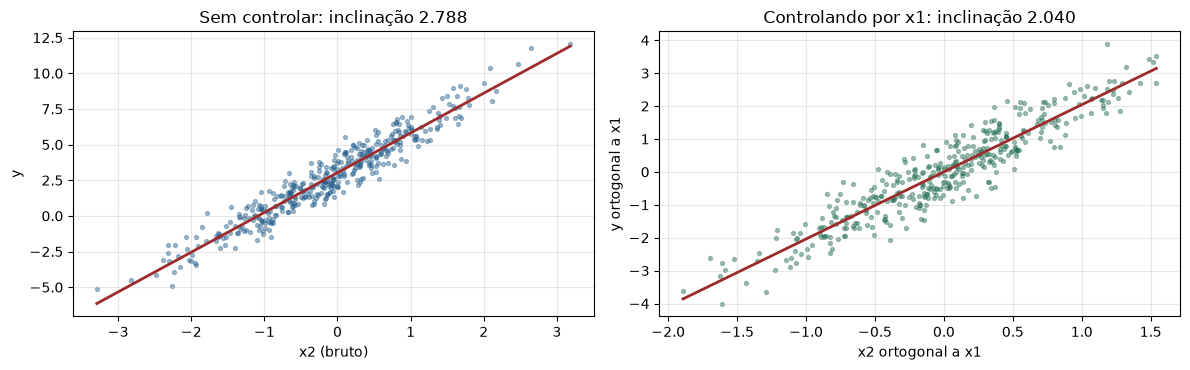

In [8]:
n = 400
x1 = rng.normal(0, 1, n)
x2 = 0.8 * x1 + rng.normal(0, 0.6, n)          # x2 é correlacionado com x1
y = 3.0 + 1.0 * x1 + 2.0 * x2 + rng.normal(0, 0.5, n)

X_completo = np.column_stack([np.ones(n), x1, x2])
beta_multipla, *_ = np.linalg.lstsq(X_completo, y, rcond=None)

# via Frisch-Waugh-Lovell: remova x1 de x2 E de y, depois regrida os resíduos
X1 = np.column_stack([np.ones(n), x1])
res_x2 = x2 - X1 @ np.linalg.lstsq(X1, x2, rcond=None)[0]
res_y = y - X1 @ np.linalg.lstsq(X1, y, rcond=None)[0]
beta_fwl = np.dot(res_x2, res_y) / np.dot(res_x2, res_x2)

# regressão simples de y em x2, sem controlar por x1
beta_simples = np.linalg.lstsq(np.column_stack([np.ones(n), x2]), y, rcond=None)[0][1]

print(f"coeficiente de x2 na regressão MÚLTIPLA   {beta_multipla[2]:.6f}")
print(f"coeficiente via Frisch-Waugh-Lovell       {beta_fwl:.6f}   <- idênticos")
print(f"coeficiente na regressão SIMPLES de y~x2  {beta_simples:.6f}   <- viesado")
print(f"\nvalor verdadeiro: 2,0")
print("A regressão simples atribui a x2 parte do efeito de x1, porque eles")
print("compartilham direção. 'Controlar' = ortogonalizar.")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].scatter(x2, y, s=8, alpha=0.4, color=AZUL)
axes[0].set_xlabel("x2 (bruto)"); axes[0].set_ylabel("y")
axes[0].set_title(f"Sem controlar: inclinação {beta_simples:.3f}")
axes[1].scatter(res_x2, res_y, s=8, alpha=0.4, color=VERDE)
axes[1].set_xlabel("x2 ortogonal a x1"); axes[1].set_ylabel("y ortogonal a x1")
axes[1].set_title(f"Controlando por x1: inclinação {beta_fwl:.3f}")
for ax, xs, ys, b in [(axes[0], x2, y, beta_simples), (axes[1], res_x2, res_y, beta_fwl)]:
    g = np.linspace(xs.min(), xs.max(), 50)
    ax.plot(g, ys.mean() + b * (g - xs.mean()), color=VERMELHO, lw=2)
plt.tight_layout(); plt.show()

> **O gráfico da direita é o "partial regression plot"** — a ferramenta certa
> para inspecionar visualmente o efeito de uma variável em regressão múltipla.
> Plotar $y$ contra $x_2$ bruto mostra a relação marginal, que não é o que o
> coeficiente estima.

## 7. Colinearidade: por que os coeficientes ficam instáveis

 corr(x1,x2)   dp de b1   dp de b2    nº condição  VIF aprox
--------------------------------------------------------------


     -0.0077     0.0547     0.0583            1.1        1.0


      0.2812     0.0609     0.0602            1.3        1.1
      0.6328     0.0744     0.0743            2.1        1.7
      0.8911     0.1345     0.1367            4.2        4.9
      0.9899     0.4033     0.4069           14.0       49.6


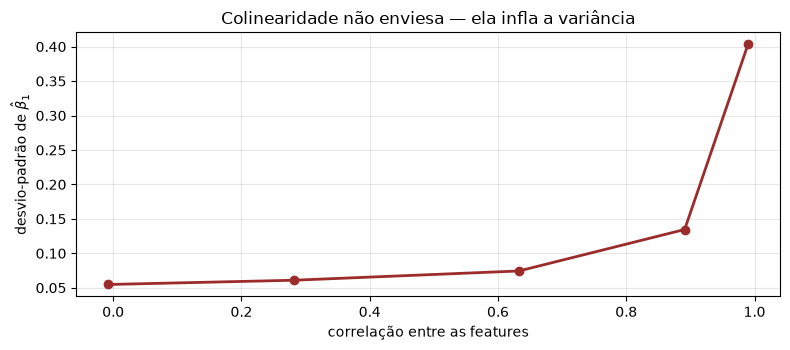

In [9]:
def experimento_colinearidade(rho, n=300, repeticoes=300):
    """Mede a variabilidade dos coeficientes conforme x1 e x2 ficam colineares."""
    coefs = []
    for _ in range(repeticoes):
        z = rng.normal(0, 1, n)
        a = rho * z + np.sqrt(1 - rho**2) * rng.normal(0, 1, n)
        b = rho * z + np.sqrt(1 - rho**2) * rng.normal(0, 1, n)
        yy = 1.0 + 2.0 * a + 3.0 * b + rng.normal(0, 1, n)
        M = np.column_stack([np.ones(n), a, b])
        coefs.append(np.linalg.lstsq(M, yy, rcond=None)[0])
    coefs = np.array(coefs)
    corr = np.corrcoef(a, b)[0, 1]
    return corr, coefs[:, 1].std(), coefs[:, 2].std(), np.linalg.cond(M)


print(f"{'corr(x1,x2)':>12s} {'dp de b1':>10s} {'dp de b2':>10s} {'nº condição':>14s} "
      f"{'VIF aprox':>10s}")
print("-" * 62)
resultados = []
for rho in [0.0, 0.5, 0.8, 0.95, 0.995]:
    corr, s1, s2, cond = experimento_colinearidade(rho)
    vif = 1 / (1 - corr**2)
    resultados.append((corr, s1, cond))
    print(f"{corr:>12.4f} {s1:>10.4f} {s2:>10.4f} {cond:>14.1f} {vif:>10.1f}")

fig, ax = plt.subplots(figsize=(8, 3.6))
corrs = [r[0] for r in resultados]
ax.plot(corrs, [r[1] for r in resultados], "o-", color=VERMELHO, lw=2)
ax.set_xlabel("correlação entre as features"); ax.set_ylabel("desvio-padrão de $\\hat\\beta_1$")
ax.set_title("Colinearidade não enviesa — ela infla a variância")
plt.tight_layout(); plt.show()

**O diagnóstico correto:** colinearidade **não enviesa** os coeficientes (a
média deles continua certa) — ela infla a **variância**. Você obtém o valor
certo em média, e uma estimativa qualquer em cada amostra.

**VIF** ($1/(1-R_j^2)$, onde $R_j^2$ é o R² de regredir a feature $j$ nas
demais) mede exatamente esse fator de inflação. VIF acima de 5–10 é o limiar
convencional de alerta.

**As saídas:** remover uma das features, combiná-las (PCA, índice), ou
**regularizar** — Ridge existe precisamente para estabilizar $X^\top X$
somando $\lambda I$ à diagonal.

## 8. Estabilidade numérica: por que ninguém usa as equações normais

In [10]:
def testa_metodos(condicao_alvo, n=200, p=8):
    """Constrói X com número de condição controlado e compara os métodos."""
    U, _ = np.linalg.qr(rng.normal(0, 1, (n, p)))
    V, _ = np.linalg.qr(rng.normal(0, 1, (p, p)))
    s = np.logspace(0, -np.log10(condicao_alvo), p)
    X = U @ np.diag(s) @ V.T
    beta_v = rng.normal(0, 1, p)
    y = X @ beta_v

    erros = {}
    try:
        erros["inv(X'X)"] = np.linalg.norm(
            np.linalg.inv(X.T @ X) @ X.T @ y - beta_v)
    except np.linalg.LinAlgError:
        erros["inv(X'X)"] = np.inf
    erros["solve(X'X)"] = np.linalg.norm(np.linalg.solve(X.T @ X, X.T @ y) - beta_v)
    Q, R = np.linalg.qr(X)
    erros["QR"] = np.linalg.norm(np.linalg.solve(R, Q.T @ y) - beta_v)
    erros["lstsq (SVD)"] = np.linalg.norm(np.linalg.lstsq(X, y, rcond=None)[0] - beta_v)
    return erros


print(f"{'cond(X)':>10s} {'cond(XtX)':>12s} " +
      "".join(f"{m:>15s}" for m in ["inv(X'X)", "solve(X'X)", "QR", "lstsq (SVD)"]))
print("-" * 74)
for cond in [1e2, 1e5, 1e8, 1e10]:
    e = testa_metodos(cond)
    print(f"{cond:>10.0e} {cond**2:>12.0e} " + "".join(f"{v:>15.3e}" for v in e.values()))

   cond(X)    cond(XtX)        inv(X'X)     solve(X'X)             QR    lstsq (SVD)
--------------------------------------------------------------------------
     1e+02        1e+04       1.840e-12      1.168e-12      1.233e-15      2.925e-15
     1e+05        1e+10       9.573e-07      1.337e-06      1.136e-12      4.372e-13
     1e+08        1e+16       1.478e+00      1.233e+00      3.546e-09      4.799e-09
     1e+10        1e+20       4.096e+00      5.060e+00      3.107e-07      2.807e-07


**A lição em uma frase:** formar $X^\top X$ **eleva ao quadrado** o número de
condição. Uma matriz com condição $10^8$ — perfeitamente comum quando as
features têm escalas muito diferentes — vira $10^{16}$, que é o limite da
precisão de um float64. Toda a informação se perde.

QR e SVD trabalham com $X$ diretamente e preservam a condição original. É por
isso que `sklearn.LinearRegression` usa `scipy.linalg.lstsq`, e não a fórmula
do livro-texto.

## 9. Regressão completa, do zero, com diagnóstico

variável             coef        EP        t          p                 IC 95%
------------------------------------------------------------------------------
intercepto        11.6146    1.5750     7.37  5.553e-13   [  8.5214,  14.7078]
x1                 0.8072    0.0235    34.33 2.459e-143   [  0.7610,   0.8534]
x2                -1.4898    0.0656   -22.70  1.055e-82   [ -1.6187,  -1.3609]
x3 (colinear com x2)     0.3949    0.0651     6.06  2.384e-09   [  0.2670,   0.5229]

n = 600   p = 4   graus de liberdade = 596
R² = 0.7577   R² ajustado = 0.7565   sigma = 5.9967
número de condição de X: 363.33
max |X' e| = 2.77e-10  (ortogonalidade, deve ser ~0)
VIF: x1=1.00  x2=1.77  x3 (colinear com x2)=1.77


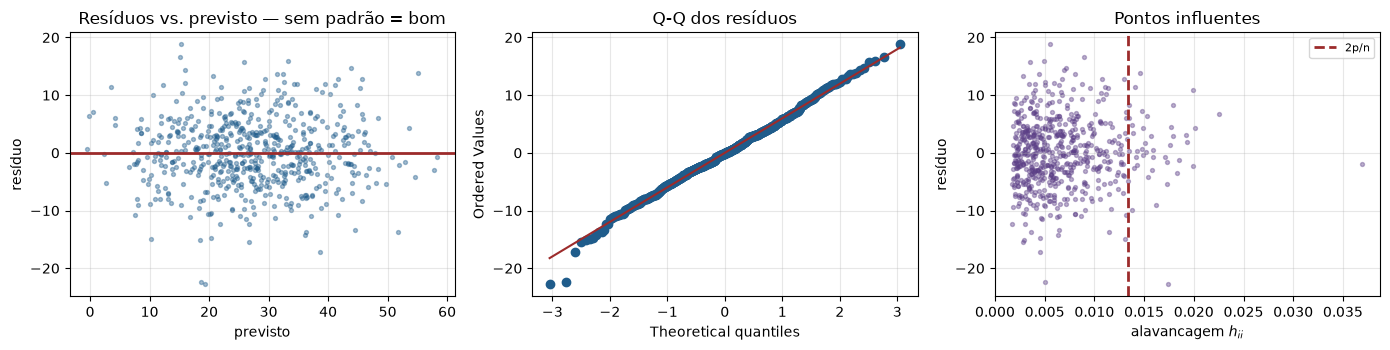

In [11]:
def regressao(X, y, nomes=None):
    """OLS via QR, com erros-padrão, ICs e diagnósticos geométricos."""
    n, p = X.shape
    nomes = nomes or [f"x{i}" for i in range(p)]

    Q, R = np.linalg.qr(X)
    beta = np.linalg.solve(R, Q.T @ y)
    y_hat = X @ beta
    e = y - y_hat

    gl = n - p
    sigma2 = (e @ e) / gl
    # (X'X)^-1 = R^-1 R^-T, sem formar X'X
    R_inv = np.linalg.inv(R)
    cov = sigma2 * (R_inv @ R_inv.T)
    ep = np.sqrt(np.diag(cov))
    t = beta / ep

    from scipy import stats as st
    p_vals = 2 * st.t.sf(np.abs(t), gl)
    tc = st.t.ppf(0.975, gl)

    sqt = np.sum((y - y.mean()) ** 2)
    r2 = 1 - (e @ e) / sqt
    r2_aj = 1 - (1 - r2) * (n - 1) / gl

    print(f"{'variável':<14s} {'coef':>10s} {'EP':>9s} {'t':>8s} {'p':>10s} "
          f"{'IC 95%':>22s}")
    print("-" * 78)
    for i, nm in enumerate(nomes):
        print(f"{nm:<14s} {beta[i]:>10.4f} {ep[i]:>9.4f} {t[i]:>8.2f} {p_vals[i]:>10.4g} "
              f"  [{beta[i]-tc*ep[i]:>8.4f}, {beta[i]+tc*ep[i]:>8.4f}]")

    print(f"\nn = {n}   p = {p}   graus de liberdade = {gl}")
    print(f"R² = {r2:.4f}   R² ajustado = {r2_aj:.4f}   sigma = {np.sqrt(sigma2):.4f}")
    print(f"número de condição de X: {np.linalg.cond(X):.2f}")
    print(f"max |X' e| = {np.abs(X.T @ e).max():.2e}  (ortogonalidade, deve ser ~0)")

    vifs = []
    for j in range(1, p):
        outras = np.delete(X, j, axis=1)
        r = X[:, j] - outras @ np.linalg.lstsq(outras, X[:, j], rcond=None)[0]
        vifs.append(1 / (1 - (1 - (r @ r) / np.sum((X[:, j] - X[:, j].mean())**2))))
    print("VIF: " + "  ".join(f"{nomes[j+1]}={v:.2f}" for j, v in enumerate(vifs)))
    return {"beta": beta, "ep": ep, "r2": r2, "residuos": e, "y_hat": y_hat}


n = 600
x1 = rng.normal(50, 10, n)
x2 = rng.normal(20, 5, n)
x3 = 0.6 * x2 + rng.normal(0, 4, n)
X = np.column_stack([np.ones(n), x1, x2, x3])
y = 12 + 0.8 * x1 - 1.5 * x2 + 0.4 * x3 + rng.normal(0, 6, n)

res = regressao(X, y, ["intercepto", "x1", "x2", "x3 (colinear com x2)"])

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
axes[0].scatter(res["y_hat"], res["residuos"], s=8, alpha=0.4, color=AZUL)
axes[0].axhline(0, color=VERMELHO, lw=2)
axes[0].set_xlabel("previsto"); axes[0].set_ylabel("resíduo")
axes[0].set_title("Resíduos vs. previsto — sem padrão = bom")

from scipy import stats as st
st.probplot(res["residuos"], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q dos resíduos")
axes[1].get_lines()[0].set_color(AZUL); axes[1].get_lines()[1].set_color(VERMELHO)

H_diag = np.sum((X @ np.linalg.inv(X.T @ X)) * X, axis=1)
axes[2].scatter(H_diag, res["residuos"], s=8, alpha=0.4, color=ROXO)
axes[2].axvline(2 * X.shape[1] / n, color=VERMELHO, lw=2, ls="--", label="2p/n")
axes[2].set_xlabel("alavancagem $h_{ii}$"); axes[2].set_ylabel("resíduo")
axes[2].set_title("Pontos influentes"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## O que levar deste notebook

- **Mínimos quadrados é uma projeção ortogonal.** A fórmula sai da exigência de
  que o resíduo seja perpendicular às features.
- **$X^\top e = 0$ por construção** — estrutura num gráfico de resíduo vs.
  feature significa não-linearidade, não correlação residual.
- **$H$ é simétrica, idempotente, e $\operatorname{tr}(H) = p$** — daí saem
  graus de liberdade e alavancagem.
- **$R^2$ é $\cos^2$ do ângulo** entre $y$ e $\hat y$ centrados; a ANOVA é
  Pitágoras.
- **"Controlar por uma variável" é ortogonalizar** (Frisch-Waugh-Lovell).
- **Colinearidade infla variância, não enviesa.** Diagnostique com VIF e número
  de condição.
- **Nunca forme $X^\top X$**: isso eleva ao quadrado o número de condição. Use
  QR ou SVD.

→ Próximo: o notebook de **exercícios** do módulo.